### Quantum Phase Estimation

In [1]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
from qiskit.circuit.library import PhaseEstimation, QFT, HGate, TGate, PhaseGate

First, create decide on the resolution of the phase estimate. Create registers for the eigenstate and eigenphase, and then initialize a quantum circuit with those registers.

In [2]:
resolution = 4  # eigenphase (fraction)
inputSize = 1  # determined by size of unitary
m = QuantumRegister(resolution, 'm')
n = QuantumRegister(inputSize, 'n')
ph = ClassicalRegister(resolution, 'ph')   # fractional representation of phase
qc = QuantumCircuit(m, n, ph)

Prepare an eigenstate. In this case, the unitary is the Hadamard gate, and we perform $R_y(-3\pi/4)$ to prepare an eigenstate.

In [3]:
qc.ry(-3*np.pi/4, n)

Now append the PhaseEstimation circuit and measure the output.

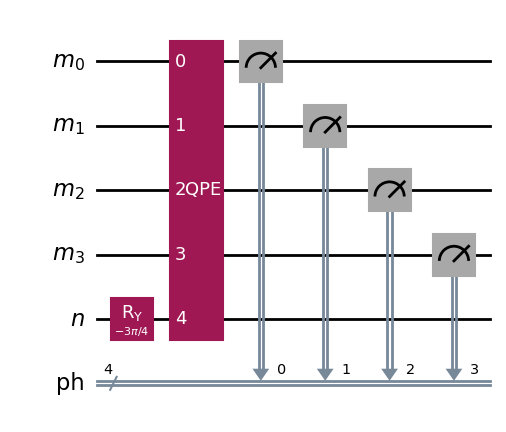

In [4]:
iq = QFT(resolution, inverse = True, name="QFT")
qc.append(PhaseEstimation(resolution, HGate(), iq), m[:]+n[:])
qc.measure(m, ph)
qc.draw('mpl')

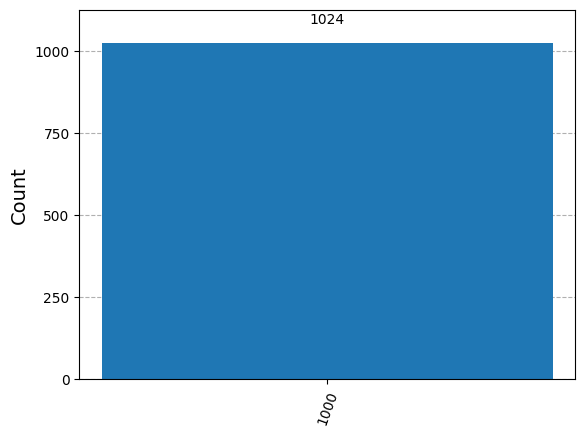

In [5]:
qsim = Aer.get_backend('qasm_simulator')
transpiled_circuit = transpile(qc, backend=qsim)
result = qsim.run(transpiled_circuit, shots=1024).result()
counts = result.get_counts(qc)
plot_histogram(counts)

We see that $\theta = (\frac{8}{16})2\pi = \pi$, which is exactly what we expect.  Let's look more carefully at the implementation of the PhaseEstimation gate.

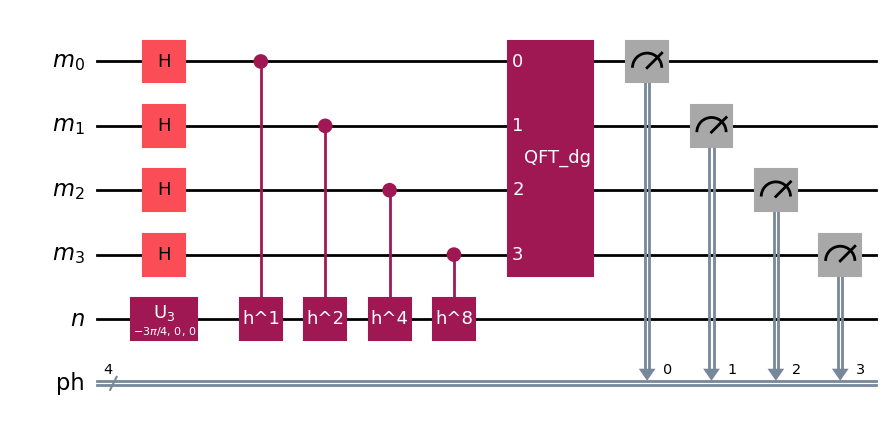

In [6]:
qc.decompose(reps=2).draw('mpl')

The $T$ gate performs a $\frac{\pi}{4}$ rotation of the $|1\rangle$ state, which means: $$T|1\rangle = e^{i\pi/4}|1\rangle.$$  If we do phase estimation, we should get the fraction $\frac{1}{8}$, which is `0010` using a four-bit fraction.

In [7]:
resolution = 4  # eigenphase (fraction)
inputSize = 1  # determined by size of unitary
m = QuantumRegister(resolution, 'm')
n = QuantumRegister(inputSize, 'n')
ph = ClassicalRegister(resolution, 'ph')   # fractional representation of phase
qc = QuantumCircuit(m, n, ph)

In [8]:
qc.x(n)  # |1> is eigenstate

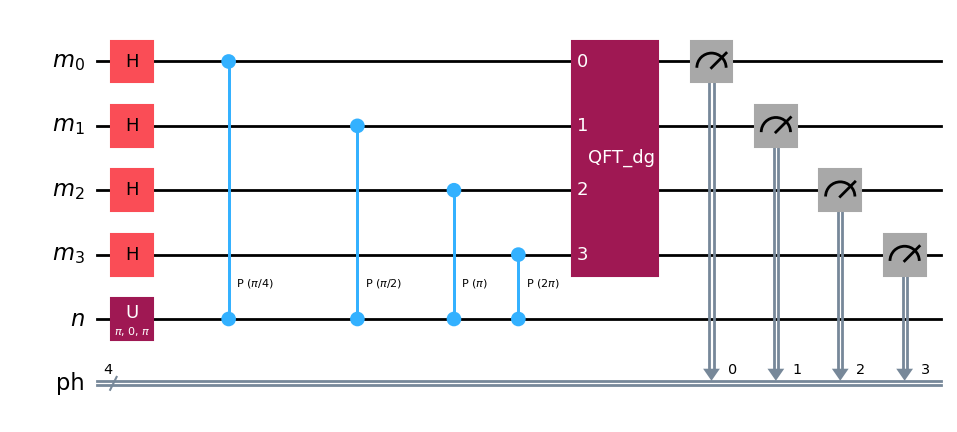

In [9]:
iq = QFT(resolution, inverse = True, name="QFT")
qc.append(PhaseEstimation(resolution, TGate(), iq), m[:]+n[:])
qc.measure(m, ph)
qc.decompose(reps=2).draw('mpl')

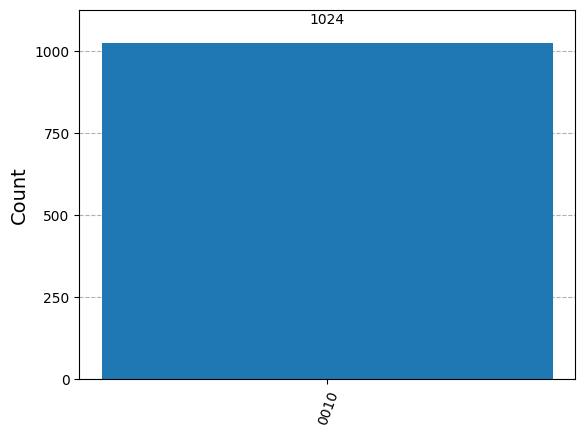

In [10]:
qsim = Aer.get_backend('qasm_simulator')
transpiled_circuit = transpile(qc, backend=qsim)
result = qsim.run(transpiled_circuit, shots=1024).result()
counts = result.get_counts(qc)
plot_histogram(counts)

For something a little more interesting, let's use a phase gate with angle $\frac{2\pi}{3}$, which should have a fraction of $\frac{1}{3}$. There's no exact representation as a four-bit fraction, so we should see something between 5 (`0101`) and 6 (`0110`).


In [11]:
resolution = 4  # eigenphase (fraction)
inputSize = 1  # determined by size of unitary
m = QuantumRegister(resolution, 'm')
n = QuantumRegister(inputSize, 'n')
ph = ClassicalRegister(resolution, 'ph')   # fractional representation of phase
qc = QuantumCircuit(m, n, ph)
qc.x(n)  # |1> is eigenstate
iq = QFT(resolution, inverse = True, name="QFT")
qc.append(PhaseEstimation(resolution, PhaseGate(2*np.pi/3), iq), m[:]+n[:])
qc.measure(m, ph)

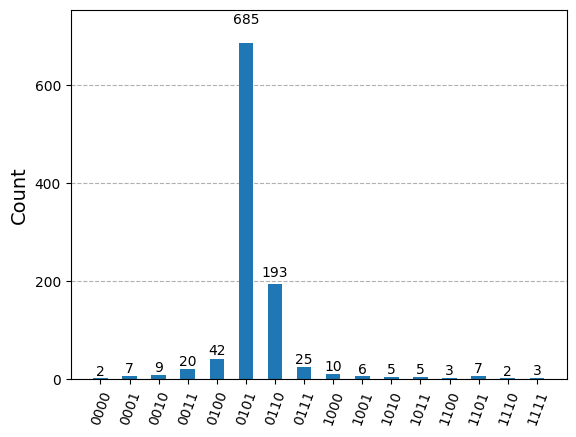

In [12]:
qsim = Aer.get_backend('qasm_simulator')
transpiled_circuit = transpile(qc, backend=qsim)
result = qsim.run(transpiled_circuit, shots=1024).result()
counts = result.get_counts(qc)
plot_histogram(counts)

Finally, we look at the case when the input is not an eigenstate, but a superposition of eigenstates. Since we know the eigenstates of the Phase gate are $|0\rangle$ and $|1\rangle$, we prepare an input of $|+\rangle$ to see what happens.

In [13]:
resolution = 4  # eigenphase (fraction)
inputSize = 1  # determined by size of unitary
m = QuantumRegister(resolution, 'm')
n = QuantumRegister(inputSize, 'n')
ph = ClassicalRegister(resolution, 'ph')   # fractional representation of phase
qc = QuantumCircuit(m, n, ph)
qc.h(n)  # |+> is a superposition of eigenstates |0> and |1>
iq = QFT(resolution, inverse = True, name="QFT")
qc.append(PhaseEstimation(resolution, PhaseGate(2*np.pi/3), iq), m[:]+n[:])
qc.measure(m, ph)

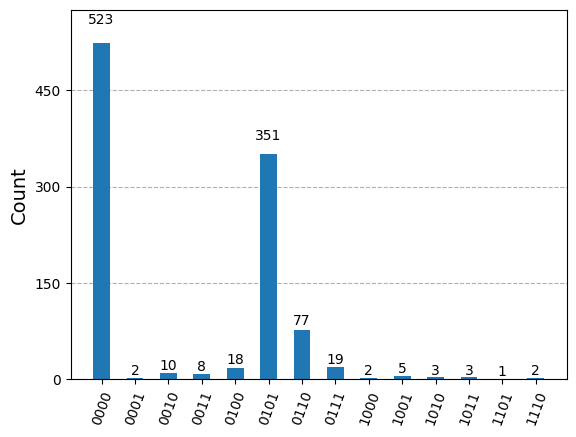

In [14]:
sim = Aer.get_backend('qasm_simulator')
transpiled_circuit = transpile(qc, backend=qsim)
result = qsim.run(transpiled_circuit, shots=1024).result()
counts = result.get_counts(qc)
plot_histogram(counts)

As expected, we see a superposition of eigenphase fractions: 0 and $\frac{1}{3}$. 